# 03 · La projection MinT : $G = (S'W^{-1}S)^{-1}S'W^{-1}$

**Bloc 2 · W37, notebook 3 sur 4.** Réconcilier, c'est **projeter** les prévisions de base sur l'espace des
vecteurs cohérents. MinT choisit la direction de projection en fonction de $W$.

| Étape | Ce qu'on montre |
|---|---|
| 1 | La géométrie sur un cas jouet en 2D : projection orthogonale (OLS) vs oblique (MinT) |
| 2 | $G$ et $P$ sur la vraie hiérarchie, en matrices |
| 3 | Les propriétés qui font foi : $P^2 = P$ et $SGS = S$ |
| 4 | BottomUp, OLS et MinT : trois choix de $G$ |
| 5 | Les prévisions avant / après réconciliation |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from w37_reconciliation import viz
from w37_reconciliation.data import build_hierarchy, make_region_channel_data, train_test_split, to_wide
from w37_reconciliation.forecasting import fit_base_forecasts, residual_matrix

viz.setup()
pd.set_option("display.precision", 3)
np.set_printoptions(precision=3, suppress=True)

## 1. Géométrie : un total et une feuille

C'est le plus petit cas possible : un total et une seule feuille, donc $S = \begin{pmatrix}1\\1\end{pmatrix}$.
L'espace cohérent est la **diagonale** $y_{\text{total}} = y_{\text{feuille}}$. Une prévision de base
$\hat{\mathbf y}$ tombe à côté, et on la ramène sur la diagonale.

- **OLS** ($W = I$) : projection **orthogonale**. On fait la moyenne simple des deux prévisions.
- **MinT** ($W = \mathrm{diag}(\sigma^2_{\text{tot}}, \sigma^2_{\text{feuille}})$) : projection **oblique**.
  On fait davantage confiance à la série dont l'erreur de base est la plus faible. Le point retenu est celui où une
  ellipse d'iso-distance de Mahalanobis (centrée sur $\hat{\mathbf y}$, de forme $W$) touche la diagonale.

In [2]:
from w37_reconciliation.mint import mint_projection
S_toy = np.array([[1.0], [1.0]])
y_base = np.array([120.0, 100.0])                       # total prévu 120, feuille prévue 100
W_toy = np.diag([1.0, 9.0])                             # le total est réputé 3× plus précis (σ = 1 vs 3)
_, P_ols = mint_projection(S_toy, np.eye(2))
_, P_mint = mint_projection(S_toy, W_toy)
p_ols, p_mint = P_ols @ y_base, P_mint @ y_base
display(pd.DataFrame({"base ŷ": y_base, "OLS (orthogonale)": p_ols, "MinT (oblique)": p_mint},
                     index=["total", "feuille"]))

,base ŷ,OLS (orthogonale),MinT (oblique)
total,120.0,110.0,118.0
feuille,100.0,110.0,118.0


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


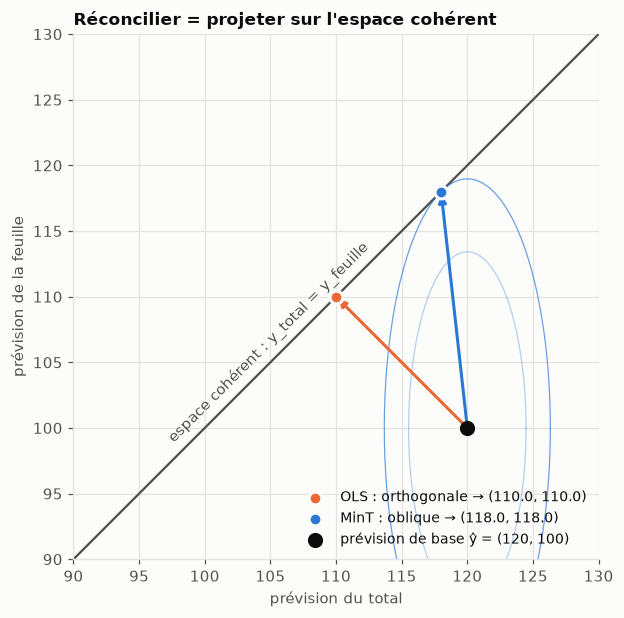

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
lim = (90, 130)
ax.plot(lim, lim, color=viz.TEXT_2, lw=1.5)
ax.text(97, 99.5, "espace cohérent : y_total = y_feuille", color=viz.TEXT_2, rotation=45,
        rotation_mode="anchor", ha="left", va="top")
# ellipses de Mahalanobis (forme W) centrées sur la prévision de base
t = np.linspace(0, 2 * np.pi, 300)
d2 = (y_base - p_mint) @ np.linalg.inv(W_toy) @ (y_base - p_mint)
for k in (0.5, 1.0):
    ax.plot(y_base[0] + np.sqrt(k * d2) * 1 * np.cos(t), y_base[1] + np.sqrt(k * d2) * 3 * np.sin(t),
            color=viz.BLUE, lw=0.8, alpha=0.35 if k < 1 else 0.7)
for p, color, name in [(p_ols, viz.ORANGE, "OLS : orthogonale"), (p_mint, viz.BLUE, "MinT : oblique")]:
    ax.annotate("", xy=p, xytext=y_base, arrowprops=dict(arrowstyle="-|>", color=color, lw=2))
    ax.scatter(*p, s=70, color=color, zorder=3, edgecolor=viz.SURFACE, linewidth=2, label=f"{name} → ({p[0]:.1f}, {p[1]:.1f})")
ax.scatter(*y_base, s=80, color=viz.TEXT, zorder=3, label="prévision de base ŷ = (120, 100)")
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.set_xlabel("prévision du total"); ax.set_ylabel("prévision de la feuille")
ax.set_title("Réconcilier = projeter sur l'espace cohérent")
ax.legend(loc="lower right", fontsize=9)
plt.show()

**Lecture.** OLS coupe la poire en deux (110, 110). MinT fait confiance au total, dont la variance d'erreur est
9 fois plus faible : il le bouge peu (118) et corrige surtout la feuille. Les poids sont $1/\sigma^2$
normalisés : $(1\cdot 120 + \tfrac19 \cdot 100)/(1 + \tfrac19) = 118$.

## 2. Sur la vraie hiérarchie : $G$ puis $P$

On repart de $W$ (notebook 02). Le calcul tient en deux lignes :

```python
G = np.linalg.solve(S.T @ Wi @ S, S.T @ Wi)   # (nb × m) = (S'W⁻¹S)⁻¹ S'W⁻¹
P = S @ G                                      # (m × m)
```

On utilise `solve` plutôt que d'inverser explicitement $S'W^{-1}S$ : c'est plus stable numériquement.

In [4]:
# Mêmes données et mêmes prévisions que le notebook 01 (tout est déterministe, graine 0).
hier = build_hierarchy(make_region_channel_data(n=80, seed=0))
S, order = hier.S, hier.order
labels = viz.short(order)
train, test = train_test_split(hier.Y_df, h=8)
Y_hat, Y_fit = fit_base_forecasts(train, h=8)
E = residual_matrix(Y_fit, order)            # résidus one-step in-sample (T × m)
T, m = E.shape
print(f"T = {T} instants, m = {m} séries, nb = {S.shape[1]} feuilles")

T = 72 instants, m = 6 séries, nb = 4 feuilles


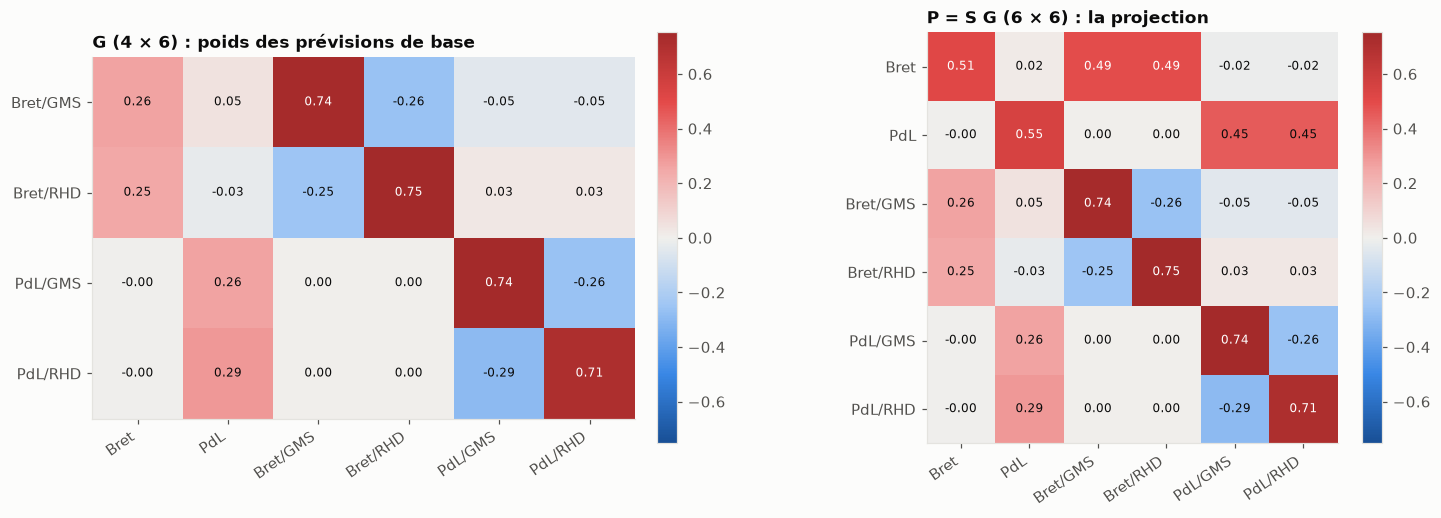

In [5]:
from w37_reconciliation.mint import shrunk_covariance, reconcile, unbiasedness_error, incoherence
cov = shrunk_covariance(E)
G, P = mint_projection(S, cov.W)
fig, axs = plt.subplots(1, 2, figsize=(13, 4.6), layout="constrained", gridspec_kw={"width_ratios": [1, 1.1]})
viz.heatmap(axs[0], G, labels_x=labels, labels_y=labels[2:], diverging=True,
            title="G (4 × 6) : poids des prévisions de base")
viz.heatmap(axs[1], P, labels, diverging=True, title="P = S G (6 × 6) : la projection")
plt.show()

**Lecture de G.** La ligne « Bret/GMS » dit comment la feuille réconciliée Bretagne/GMS se construit à partir des 6
prévisions de base :

- un gros poids sur sa propre prévision de base ;
- une contribution de la prévision de la région Bretagne, qui transmet l'information d'en haut ;
- des poids **négatifs** sur les autres feuilles de la même région, qui répartissent l'écart d'incohérence.

Ce **partage d'information entre niveaux** explique le gain de précision qu'on observe souvent, sans qu'il soit
jamais garanti.

## 3. Les propriétés qui font foi

In [6]:
checks = pd.DataFrame({
    "propriété": ["P² = P (projection)", "P S = S  ⟺  SGS = S (absence de biais préservée)", "G S = I (les feuilles cohérentes sont inchangées)"],
    "max |écart|": [np.abs(P @ P - P).max(), unbiasedness_error(P, S), np.abs(G @ S - np.eye(S.shape[1])).max()],
})
checks["OK (< 1e-12)"] = checks["max |écart|"] < 1e-12
display(checks.style.format({"max |écart|": "{:.1e}"}))
print("valeurs propres de P :", np.round(np.sort(np.linalg.eigvals(P).real)[::-1], 10))

,propriété,max |écart|,OK (< 1e-12)
0,P² = P (projection),2.2e-16,True
1,P S = S ⟺ SGS = S (absence de biais préservée),2.2e-16,True
2,G S = I (les feuilles cohérentes sont inchangées),2.2e-16,True


valeurs propres de P : [ 1.  1.  1.  1.  0. -0.]


Les valeurs propres de $P$ valent toutes **1** ou **0** : quatre fois 1 (la dimension de l'espace cohérent, nb = 4)
et deux fois 0 (les deux directions d'incohérence, écrasées). C'est la signature d'une projection.

## 4. Trois choix de $G$ : BottomUp, OLS, MinT

Toute matrice $G$ qui vérifie $SGS = S$ donne une réconciliation non biaisée. Ce qui distingue les méthodes, c'est
**à quelles prévisions de base elles font confiance**.

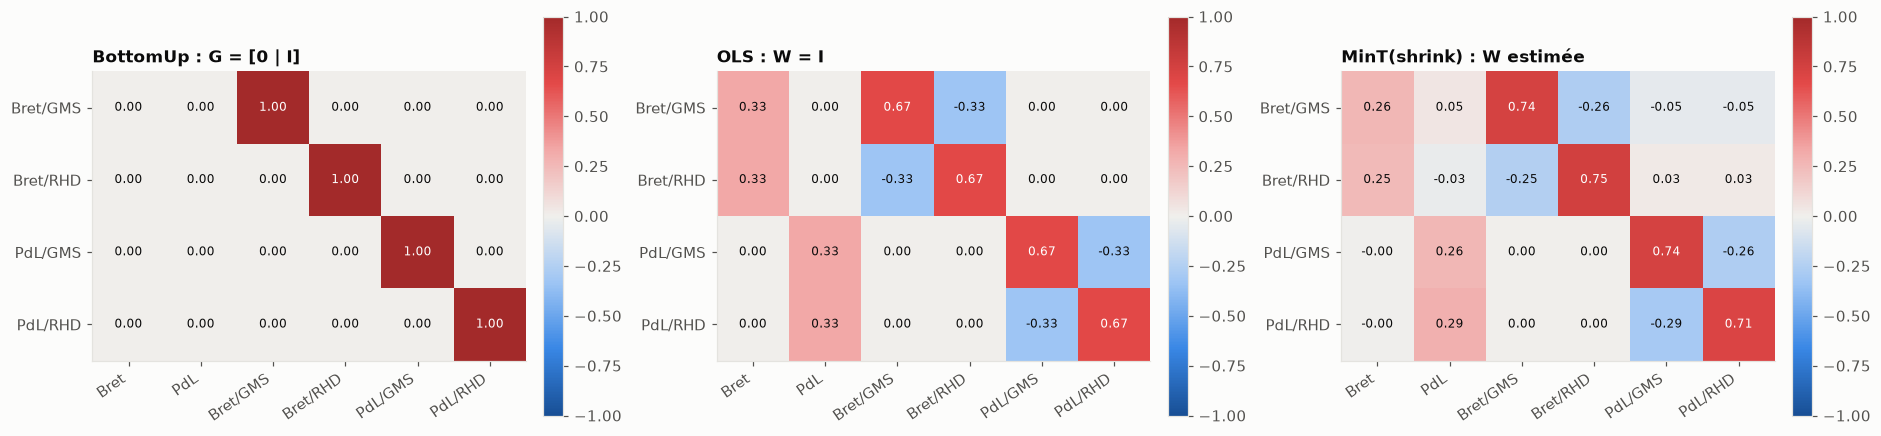

In [7]:
nb = S.shape[1]
G_bu = np.hstack([np.zeros((nb, m - nb)), np.eye(nb)])      # BottomUp : ignore les agrégats
G_ols, _ = mint_projection(S, np.eye(m))                     # OLS : W = I
fig, axs = plt.subplots(1, 3, figsize=(17, 4), layout="constrained")
for ax, (Gx, name) in zip(axs, [(G_bu, "BottomUp : G = [0 | I]"), (G_ols, "OLS : W = I"), (G, "MinT(shrink) : W estimée")]):
    viz.heatmap(ax, Gx, labels_x=labels, labels_y=labels[2:], diverging=True, vmax=1, title=name)
plt.show()

## 5. Les prévisions avant / après

On applique $\tilde{\mathbf y} = P\,\hat{\mathbf y}$ à chaque horizon. L'incohérence tombe à la précision
machine. Les ajustements restent petits ici (quelques dixièmes d'unité), parce que les prévisions de base étaient
déjà presque cohérentes.

In [8]:
y_hat = to_wide(Y_hat, order, "AutoETS").to_numpy()
y_rec = reconcile(y_hat, P)
h1 = pd.DataFrame({"base ŷ": y_hat[0], "réconciliée ỹ": y_rec[0], "ajustement ỹ − ŷ": y_rec[0] - y_hat[0]}, index=order)
display(Markdown("**Horizon h = 1**")); display(h1)
inc = pd.DataFrame({"base": [incoherence(y_hat[[k]], S) for k in range(8)],
                    "réconciliée": [incoherence(y_rec[[k]], S) for k in range(8)]},
                   index=[f"h={k + 1}" for k in range(8)])
display(inc.style.format("{:.1e}"))

**Horizon h = 1**

,base ŷ,réconciliée ỹ,ajustement ỹ − ŷ
Bretagne,288.658,288.651,-0.008
PaysLoire,206.709,206.562,-0.147
Bretagne/GMS,159.202,159.225,0.022
Bretagne/RHD,129.429,129.426,-0.003
PaysLoire/GMS,117.615,117.700,0.085
PaysLoire/RHD,88.767,88.862,0.095


,base,réconciliée
h=1,3.3e-01,5.7e-14
h=2,3.2e-01,0.0e+00
h=3,3.2e-01,5.7e-14
h=4,3.1e-01,5.7e-14
h=5,3.3e-01,5.7e-14
h=6,3.2e-01,0.0e+00
h=7,3.2e-01,5.7e-14
h=8,3.1e-01,5.7e-14


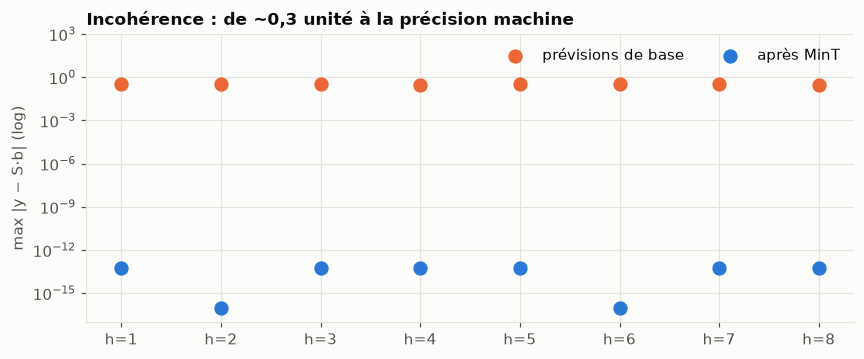

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.4))
x = np.arange(8)
ax.scatter(x, inc["base"], s=70, color=viz.ORANGE, label="prévisions de base", zorder=3)
ax.scatter(x, np.maximum(inc["réconciliée"], 1e-16), s=70, color=viz.BLUE, label="après MinT", zorder=3)
ax.set_yscale("log"); ax.set_xticks(x, inc.index)
ax.set_ylabel("max |y − S·b| (log)")
ax.set_ylim(1e-17, 1e3)
ax.set_title("Incohérence : de ~0,3 unité à la précision machine")
ax.legend(loc="upper right", ncol=2)
plt.show()

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


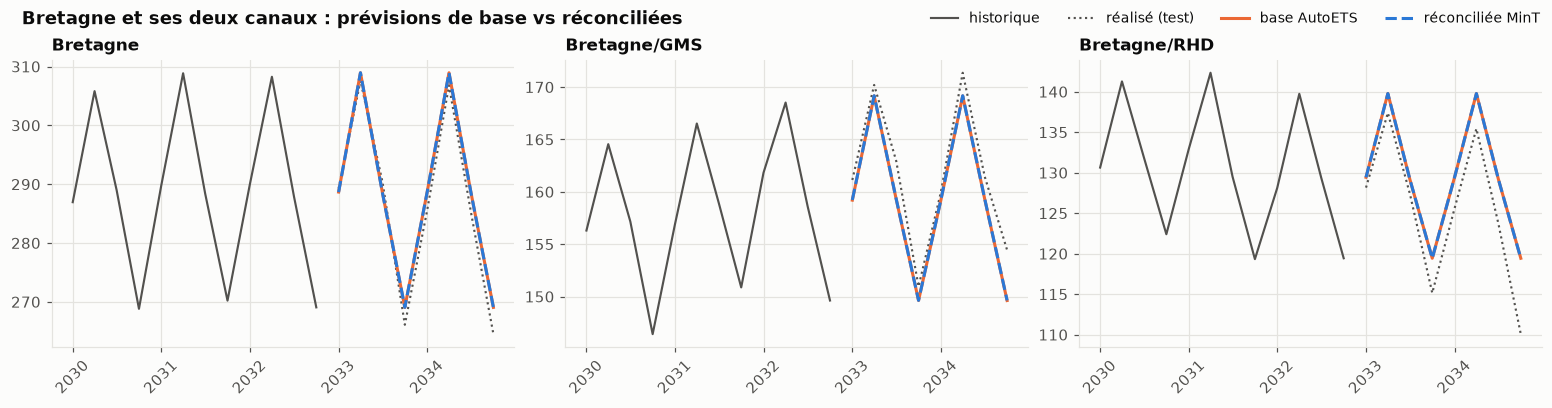

In [10]:
hist = to_wide(train, order).iloc[-12:]
actual = to_wide(test, order)
idx = to_wide(Y_hat, order, "AutoETS").index
fig, axs = plt.subplots(1, 3, figsize=(14, 3.6), sharey=False, layout="constrained")
for ax, name in zip(axs, ["Bretagne", "Bretagne/GMS", "Bretagne/RHD"]):
    j = order.index(name)
    ax.plot(hist.index, hist[name], color=viz.TEXT_2, lw=1.4, label="historique")
    ax.plot(actual.index, actual[name], color=viz.TEXT_2, lw=1.4, ls=":", label="réalisé (test)")
    ax.plot(idx, y_hat[:, j], color=viz.ORANGE, label="base AutoETS")
    ax.plot(idx, y_rec[:, j], color=viz.BLUE, ls="--", label="réconciliée MinT")
    ax.set_title(name); ax.tick_params(axis="x", labelrotation=45)
handles, lbls = axs[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc="upper right", ncol=4, fontsize=9)
fig.suptitle("Bretagne et ses deux canaux : prévisions de base vs réconciliées", x=0.01, ha="left", fontweight="semibold")
plt.show()

## À retenir

- $P = S(S'W^{-1}S)^{-1}S'W^{-1}$ est une **projection oblique**. Ses valeurs propres valent 0 ou 1, et $P^2 = P$.
- $SGS = S$ **préserve** l'absence de biais, mais ne la **crée** pas : une prévision de base biaisée contamine
  toutes les feuilles (bloc 4).
- BottomUp, OLS et MinT sont trois choix de $G$ ; MinT laisse $W$ décider.

→ Notebook **04** : on compare ce calcul à `HierarchicalForecast`, et on explique pourquoi l'écart n'est pas nul.